# Donor Split Impact Analysis

This notebook analyzes the impact of donor-aware cross-validation on model performance across different embedding types.

**Comparison**: Standard CV (potential donor leakage) vs Donor-Aware CV (GroupKFold, no leakage)

**Models**: GenePT, scGPT, GenePT+scGPT, Transcriptformer, GenePT+Transcriptformer

**Classifier**: Logistic Regression only

**Tissues**: Blood, Bone_Marrow, Thymus (tissues with 3 donors)

Note: Lung and Mammary only have 1 donor each, so donor-aware CV is not applicable.

In [1]:
# Setup
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Add repo to path
repo_dir = Path.cwd().parent
if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

data_dir = repo_dir / 'data'
results_dir = data_dir / 'cz_benchmark' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Repository: {repo_dir}")
print(f"Data directory: {data_dir}")

Repository: /Users/rj/personal/GenePT-tools
Data directory: /Users/rj/personal/GenePT-tools/data


## Configuration

In [2]:
# Tissues with 3 donors (based on previous analysis)
TISSUES = ['Blood', 'Bone_Marrow', 'Thymus']

# Embedding types in desired order
EMBEDDINGS = [
    'genept_1024d',
    'scgpt',
    'genept_scgpt',
    'transcriptformer',
    'genept_transcriptformer'
]

EMBEDDING_NAMES = {
    'genept_1024d': 'GenePT',
    'scgpt': 'scGPT',
    'genept_scgpt': 'GenePT + scGPT',
    'transcriptformer': 'Transcriptformer',
    'genept_transcriptformer': 'GenePT + Transcriptformer'
}

# Cross-validation settings
N_FOLDS = 3  # Must match number of donors
RANDOM_SEED = 42
MIN_CLASS_SIZE = 10

# Paths
TABULA_SAPIENS_DIR = Path('/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark')
EMBEDDING_DIR = data_dir / 'cz_benchmark' / 'embeddings'

print(f"Analyzing {len(TISSUES)} tissues with {len(EMBEDDINGS)} embedding types")
print(f"Using {N_FOLDS}-fold cross-validation (matching number of donors)")

Analyzing 3 tissues with 5 embedding types
Using 3-fold cross-validation (matching number of donors)


## Data Loading Functions

In [3]:
def load_tabula_sapiens_dataset(tissue_name: str) -> ad.AnnData:
    """Load Tabula Sapiens v2 curated dataset."""
    pattern = f"*_{tissue_name}_v2_curated.h5ad"
    files = list(TABULA_SAPIENS_DIR.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No h5ad file found for tissue: {tissue_name}")
    
    adata = sc.read_h5ad(files[0])
    
    # Handle X_original layer
    if adata.X is None or (hasattr(adata.X, 'nnz') and adata.X.nnz == 0):
        if 'X_original' in adata.layers:
            adata.X = adata.layers['X_original'].copy()
    
    # Ensure cell_type column
    if 'cell_type' not in adata.obs.columns:
        for col in ['cell_ontology_class', 'celltype', 'CellType']:
            if col in adata.obs.columns:
                adata.obs['cell_type'] = adata.obs[col]
                break
    
    return adata

def load_embeddings(tissue_name: str, embedding_type: str) -> np.ndarray:
    """Load embeddings for a tissue."""
    
    if embedding_type in ['genept_1024d', 'genept_scgpt', 'genept_transcriptformer']:
        # Combined embeddings
        path = EMBEDDING_DIR / 'combined' / f"{embedding_type}_{tissue_name}_embeddings.parquet"
        df = pd.read_parquet(path)
        emb_cols = [col for col in df.columns if col.startswith(embedding_type)]
    else:
        # Foundation model embeddings
        if embedding_type == 'scgpt':
            path = EMBEDDING_DIR / 'scgpt' / f"scgpt_{tissue_name}_embeddings.parquet"
            df = pd.read_parquet(path)
            emb_cols = [col for col in df.columns if col.startswith('embedding_')]
        elif embedding_type == 'transcriptformer':
            path = EMBEDDING_DIR / 'transcriptformer' / f"transcriptformer_tf_metazoa_{tissue_name}_embeddings.parquet"
            df = pd.read_parquet(path)
            emb_cols = [col for col in df.columns if col.startswith('emb_')]
    
    return df[emb_cols].values

print("✓ Data loading functions defined")

✓ Data loading functions defined


## Evaluation Functions

In [4]:
def filter_classes(y, donor_ids, min_class_size=10):
    """Filter out classes with too few samples."""
    unique, counts = np.unique(y, return_counts=True)
    valid_classes = unique[counts >= min_class_size]
    mask = np.isin(y, valid_classes)
    return mask

def run_standard_cv(X, y, n_folds=3, random_seed=42):
    """Run standard stratified k-fold cross-validation (potential donor leakage)."""
    
    # Stratified K-Fold
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
    
    fold_metrics = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # Train logistic regression
        model = LogisticRegression(max_iter=1000, random_state=random_seed)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        fold_metrics.append({
            'accuracy': accuracy_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'recall': recall_score(y_test, y_pred, average='macro', zero_division=0)
        })
    
    # Average across folds
    return {
        'accuracy': np.mean([m['accuracy'] for m in fold_metrics]),
        'f1': np.mean([m['f1'] for m in fold_metrics]),
        'precision': np.mean([m['precision'] for m in fold_metrics]),
        'recall': np.mean([m['recall'] for m in fold_metrics])
    }

def run_donor_aware_cv(X, y, donor_ids, n_folds=3, random_seed=42):
    """Run donor-aware cross-validation using GroupKFold (no donor leakage)."""
    
    # GroupKFold splits by donor
    cv = GroupKFold(n_splits=n_folds)
    
    fold_metrics = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=donor_ids)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # Train logistic regression
        model = LogisticRegression(max_iter=1000, random_state=random_seed)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        fold_metrics.append({
            'accuracy': accuracy_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'recall': recall_score(y_test, y_pred, average='macro', zero_division=0)
        })
    
    # Average across folds
    return {
        'accuracy': np.mean([m['accuracy'] for m in fold_metrics]),
        'f1': np.mean([m['f1'] for m in fold_metrics]),
        'precision': np.mean([m['precision'] for m in fold_metrics]),
        'recall': np.mean([m['recall'] for m in fold_metrics])
    }

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Run Complete Evaluation

In [5]:
# Store all results
all_results = []

print("="*80)
print("RUNNING DONOR SPLIT IMPACT ANALYSIS")
print("="*80)

for tissue in TISSUES:
    print(f"\n{'='*80}")
    print(f"Tissue: {tissue}")
    print('='*80)
    
    # Load AnnData for labels and donor IDs
    adata = load_tabula_sapiens_dataset(tissue)
    
    # Get labels and donor IDs
    labels = adata.obs['cell_type'].values
    donor_ids = adata.obs['donor_id'].values
    
    print(f"Loaded: {adata.n_obs} cells, {adata.obs['cell_type'].nunique()} cell types")
    print(f"Donors: {np.unique(donor_ids)}")
    
    # Encode labels
    unique_labels = sorted(np.unique(labels))
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_to_idx[label] for label in labels])
    
    for embedding_type in EMBEDDINGS:
        print(f"\n  {'─'*70}")
        print(f"  Embedding: {EMBEDDING_NAMES[embedding_type]}")
        print(f"  {'─'*70}")
        
        try:
            # Load embeddings
            X = load_embeddings(tissue, embedding_type)
            print(f"  Embedding shape: {X.shape}")
            
            # Filter classes with too few samples
            mask = filter_classes(y, donor_ids, MIN_CLASS_SIZE)
            X_filtered = X[mask]
            y_filtered = y[mask]
            donor_ids_filtered = donor_ids[mask]
            
            n_classes = len(np.unique(y_filtered))
            print(f"  After filtering: {X_filtered.shape[0]} cells, {n_classes} cell types")
            
            # Run standard CV
            print(f"  Running standard CV...")
            standard_results = run_standard_cv(X_filtered, y_filtered, N_FOLDS, RANDOM_SEED)
            
            # Run donor-aware CV
            print(f"  Running donor-aware CV...")
            donor_aware_results = run_donor_aware_cv(X_filtered, y_filtered, donor_ids_filtered, N_FOLDS, RANDOM_SEED)
            
            # Store results
            for cv_type, results in [('standard', standard_results), ('donor_aware', donor_aware_results)]:
                all_results.append({
                    'tissue': tissue,
                    'embedding': embedding_type,
                    'embedding_name': EMBEDDING_NAMES[embedding_type],
                    'cv_type': cv_type,
                    'accuracy': results['accuracy'],
                    'f1': results['f1'],
                    'precision': results['precision'],
                    'recall': results['recall'],
                    'n_cells': X_filtered.shape[0],
                    'n_classes': n_classes
                })
            
            # Show comparison
            print(f"  Results:")
            print(f"    Standard CV    - Acc: {standard_results['accuracy']:.4f}, F1: {standard_results['f1']:.4f}")
            print(f"    Donor-Aware CV - Acc: {donor_aware_results['accuracy']:.4f}, F1: {donor_aware_results['f1']:.4f}")
            diff_acc = standard_results['accuracy'] - donor_aware_results['accuracy']
            diff_f1 = standard_results['f1'] - donor_aware_results['f1']
            print(f"    Difference     - Acc: {diff_acc:+.4f}, F1: {diff_f1:+.4f}")
            
        except Exception as e:
            print(f"  ERROR: {str(e)}")
            import traceback
            traceback.print_exc()

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"Total results: {len(results_df)} ({len(TISSUES)} tissues × {len(EMBEDDINGS)} embeddings × 2 CV types)")

RUNNING DONOR SPLIT IMPACT ANALYSIS

Tissue: Blood
Loaded: 17802 cells, 19 cell types
Donors: ['TSP21' 'TSP25' 'TSP27']

  ──────────────────────────────────────────────────────────────────────
  Embedding: GenePT
  ──────────────────────────────────────────────────────────────────────
  Embedding shape: (17802, 1024)
  After filtering: 17788 cells, 16 cell types
  Running standard CV...
  Running donor-aware CV...
  Results:
    Standard CV    - Acc: 0.8931, F1: 0.7950
    Donor-Aware CV - Acc: 0.7391, F1: 0.4208
    Difference     - Acc: +0.1540, F1: +0.3742

  ──────────────────────────────────────────────────────────────────────
  Embedding: scGPT
  ──────────────────────────────────────────────────────────────────────
  Embedding shape: (17802, 512)
  After filtering: 17788 cells, 16 cell types
  Running standard CV...
  Running donor-aware CV...
  Results:
    Standard CV    - Acc: 0.8954, F1: 0.8046
    Donor-Aware CV - Acc: 0.7487, F1: 0.4671
    Difference     - Acc: +0.1466, 

## Analysis: Per-Tissue Results

In [6]:
print("\n" + "="*80)
print("PER-TISSUE RESULTS")
print("="*80)

for tissue in TISSUES:
    print(f"\n{'='*80}")
    print(f"Tissue: {tissue}")
    print('='*80)
    
    tissue_df = results_df[results_df['tissue'] == tissue].copy()
    
    # Create pivot tables
    print("\nAccuracy:")
    acc_pivot = tissue_df.pivot_table(index='embedding_name', columns='cv_type', values='accuracy')
    acc_pivot = acc_pivot[['standard', 'donor_aware']]  # Order columns
    acc_pivot['difference'] = acc_pivot['standard'] - acc_pivot['donor_aware']
    print(acc_pivot.to_string())
    
    print("\nF1 Score:")
    f1_pivot = tissue_df.pivot_table(index='embedding_name', columns='cv_type', values='f1')
    f1_pivot = f1_pivot[['standard', 'donor_aware']]  # Order columns
    f1_pivot['difference'] = f1_pivot['standard'] - f1_pivot['donor_aware']
    print(f1_pivot.to_string())


PER-TISSUE RESULTS

Tissue: Blood

Accuracy:
cv_type                    standard  donor_aware  difference
embedding_name                                              
GenePT                     0.893130     0.739084    0.154046
GenePT + Transcriptformer  0.902743     0.744291    0.158452
GenePT + scGPT             0.899820     0.746368    0.153452
Transcriptformer           0.901619     0.743130    0.158489
scGPT                      0.895379     0.748734    0.146645

F1 Score:
cv_type                    standard  donor_aware  difference
embedding_name                                              
GenePT                     0.794990     0.420813    0.374177
GenePT + Transcriptformer  0.817343     0.485811    0.331532
GenePT + scGPT             0.810516     0.457048    0.353469
Transcriptformer           0.818897     0.504865    0.314033
scGPT                      0.804628     0.467113    0.337514

Tissue: Bone_Marrow

Accuracy:
cv_type                    standard  donor_aware  differe

## Analysis: Averaged Over Tissues

In [7]:
print("\n" + "="*80)
print("AVERAGED OVER ALL TISSUES")
print("="*80)

# Average by embedding and CV type
avg_results = results_df.groupby(['embedding_name', 'cv_type']).agg({
    'accuracy': 'mean',
    'f1': 'mean',
    'precision': 'mean',
    'recall': 'mean'
}).reset_index()

# Ensure correct ordering
model_order = ['GenePT', 'scGPT', 'GenePT + scGPT', 'Transcriptformer', 'GenePT + Transcriptformer']
avg_results['embedding_name'] = pd.Categorical(avg_results['embedding_name'], categories=model_order, ordered=True)
avg_results = avg_results.sort_values(['embedding_name', 'cv_type'])

print("\nAccuracy:")
acc_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='accuracy')
acc_avg = acc_avg[['standard', 'donor_aware']]  # Order columns
acc_avg['difference'] = acc_avg['standard'] - acc_avg['donor_aware']
print(acc_avg.to_string())

print("\nF1 Score:")
f1_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='f1')
f1_avg = f1_avg[['standard', 'donor_aware']]  # Order columns
f1_avg['difference'] = f1_avg['standard'] - f1_avg['donor_aware']
print(f1_avg.to_string())

print("\nPrecision:")
prec_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='precision')
prec_avg = prec_avg[['standard', 'donor_aware']]  # Order columns
prec_avg['difference'] = prec_avg['standard'] - prec_avg['donor_aware']
print(prec_avg.to_string())

print("\nRecall:")
rec_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='recall')
rec_avg = rec_avg[['standard', 'donor_aware']]  # Order columns
rec_avg['difference'] = rec_avg['standard'] - rec_avg['donor_aware']
print(rec_avg.to_string())


AVERAGED OVER ALL TISSUES

Accuracy:
cv_type                    standard  donor_aware  difference
embedding_name                                              
GenePT                     0.873596     0.736275    0.137321
scGPT                      0.882257     0.763377    0.118880
GenePT + scGPT             0.887145     0.757663    0.129482
Transcriptformer           0.893222     0.776001    0.117221
GenePT + Transcriptformer  0.895366     0.782076    0.113290

F1 Score:
cv_type                    standard  donor_aware  difference
embedding_name                                              
GenePT                     0.771657     0.531339    0.240318
scGPT                      0.796670     0.566073    0.230597
GenePT + scGPT             0.805285     0.578645    0.226641
Transcriptformer           0.815263     0.599613    0.215650
GenePT + Transcriptformer  0.815155     0.599503    0.215652

Precision:
cv_type                    standard  donor_aware  difference
embedding_name          

## Visualization


Saved figure to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/donor_split_impact_analysis.png


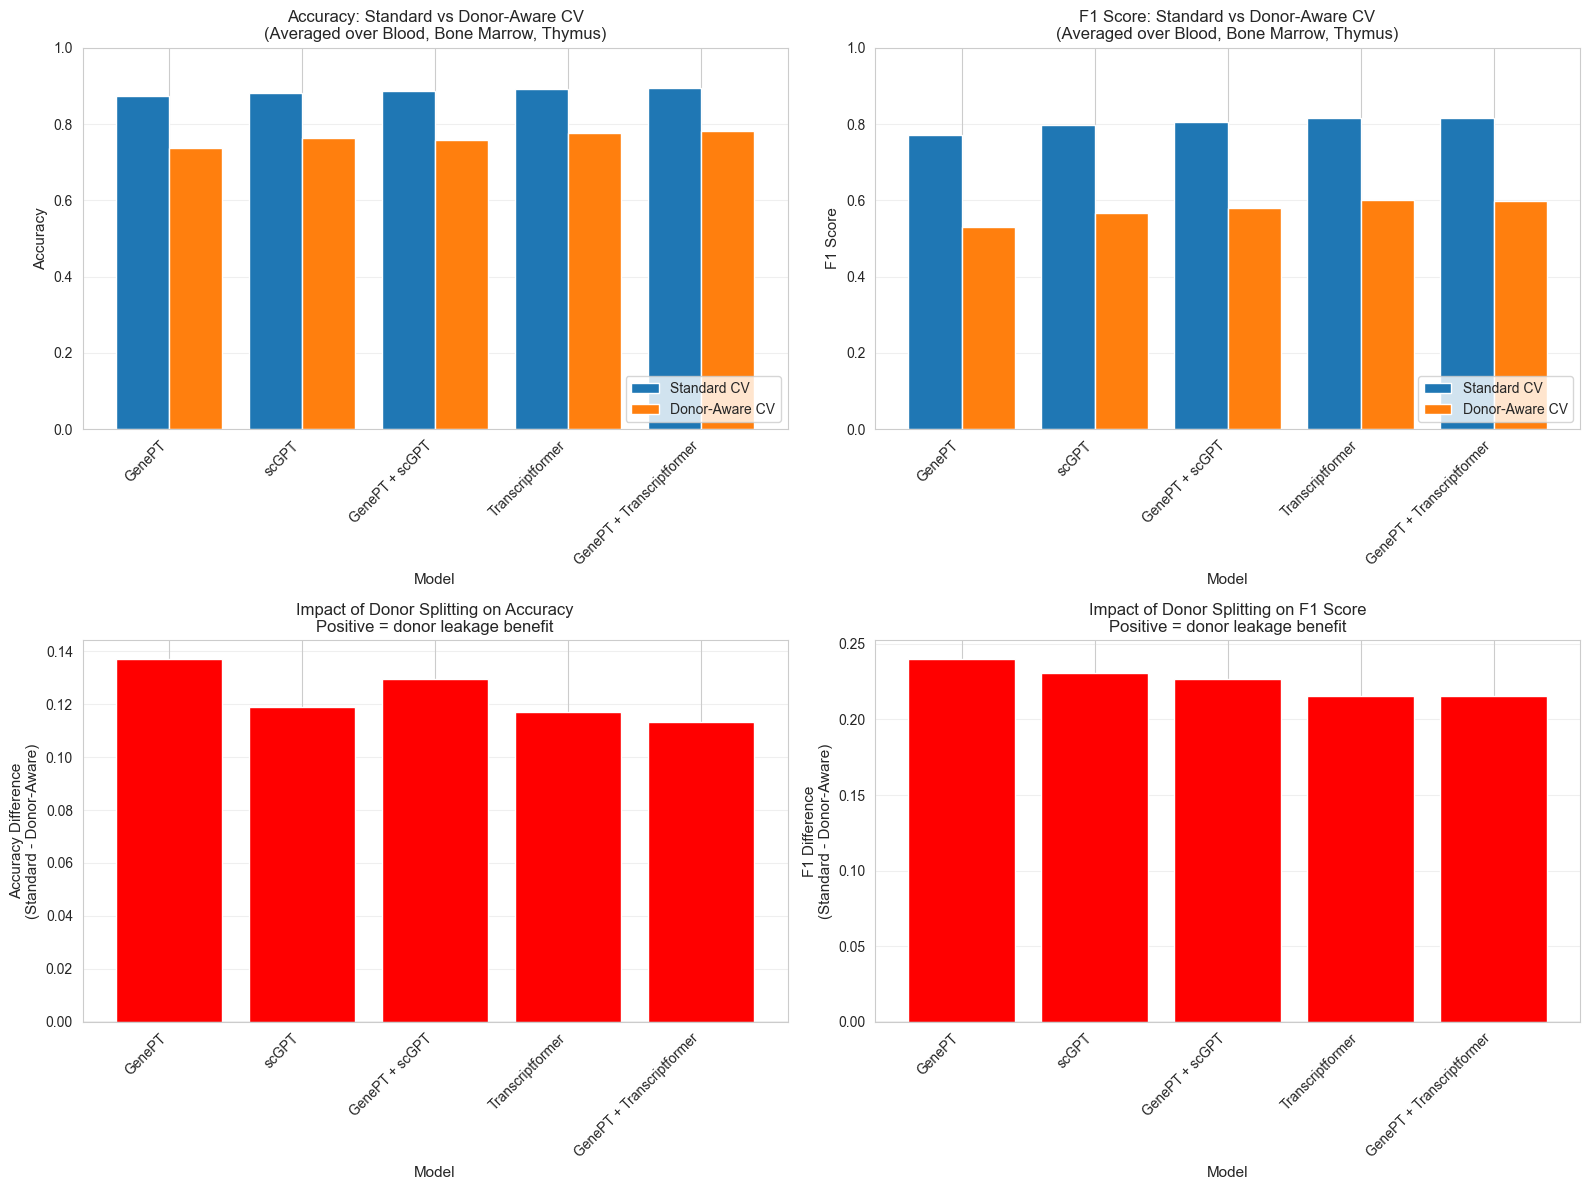

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison (averaged)
ax = axes[0, 0]
acc_avg[['standard', 'donor_aware']].plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: Standard vs Donor-Aware CV\n(Averaged over Blood, Bone Marrow, Thymus)', fontsize=12)
ax.legend(['Standard CV', 'Donor-Aware CV'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0., 1.0])

# Plot 2: F1 comparison (averaged)
ax = axes[0, 1]
f1_avg[['standard', 'donor_aware']].plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 Score: Standard vs Donor-Aware CV\n(Averaged over Blood, Bone Marrow, Thymus)', fontsize=12)
ax.legend(['Standard CV', 'Donor-Aware CV'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0., 1.0])

# Plot 3: Accuracy difference (impact of donor splitting)
ax = axes[1, 0]
acc_avg['difference'].plot(kind='bar', ax=ax, color=['red' if x > 0 else 'green' for x in acc_avg['difference']], width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Accuracy Difference\n(Standard - Donor-Aware)', fontsize=11)
ax.set_title('Impact of Donor Splitting on Accuracy\nPositive = donor leakage benefit', fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Plot 4: F1 difference (impact of donor splitting)
ax = axes[1, 1]
f1_avg['difference'].plot(kind='bar', ax=ax, color=['red' if x > 0 else 'green' for x in f1_avg['difference']], width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('F1 Difference\n(Standard - Donor-Aware)', fontsize=11)
ax.set_title('Impact of Donor Splitting on F1 Score\nPositive = donor leakage benefit', fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save figure
fig_path = results_dir / 'donor_split_impact_analysis.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nSaved figure to: {fig_path}")

plt.show()

## Save Results

In [11]:
# Save detailed results
results_df.to_csv(results_dir / 'donor_split_impact_detailed.csv', index=False)
print(f"Saved detailed results to: {results_dir / 'donor_split_impact_detailed.csv'}")

# Save averaged results
avg_results.to_csv(results_dir / 'donor_split_impact_averaged.csv', index=False)
print(f"Saved averaged results to: {results_dir / 'donor_split_impact_averaged.csv'}")

# Save pivot tables
acc_avg.to_csv(results_dir / 'donor_split_accuracy_comparison.csv')
f1_avg.to_csv(results_dir / 'donor_split_f1_comparison.csv')
print(f"Saved pivot tables to results directory")

print("\n" + "="*80)
print("DONOR SPLIT IMPACT ANALYSIS COMPLETE")
print("="*80)
print(f"\nAnalyzed {len(TISSUES)} tissues with {len(EMBEDDINGS)} embedding types")
print(f"Comparison: Standard CV vs Donor-Aware CV (GroupKFold)")
print(f"Classifier: Logistic Regression")
print(f"\nKey Finding: Difference values show the benefit from potential donor leakage.")
print(f"Positive difference = Standard CV performs better (suggests donor leakage)")
print(f"Negative difference = Donor-aware CV performs better (unlikely but possible with better generalization)")

Saved detailed results to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/donor_split_impact_detailed.csv
Saved averaged results to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/donor_split_impact_averaged.csv
Saved pivot tables to results directory

DONOR SPLIT IMPACT ANALYSIS COMPLETE

Analyzed 3 tissues with 5 embedding types
Comparison: Standard CV vs Donor-Aware CV (GroupKFold)
Classifier: Logistic Regression

Key Finding: Difference values show the benefit from potential donor leakage.
Positive difference = Standard CV performs better (suggests donor leakage)
Negative difference = Donor-aware CV performs better (unlikely but possible with better generalization)
